# FastF1 Exploratory Data Analysis


## Query for Available Seasons

In [5]:
import fastf1
import datetime

from pathlib import Path
import pandas as pd

# Get the project root (up one level from 'notebooks')
project_root = Path.cwd().parent

# Setup caching to speed up repeated requests
fastf1.Cache.enable_cache(f"{project_root}/.fastf1") 

def get_available_seasons(start_year=1950):
    current_year = datetime.datetime.now().year
    available = []
    
    for year in range(start_year, current_year + 1):
        try:
            # FastF1 uses Ergast for older seasons, which supports back to 1950
            schedule = fastf1.get_event_schedule(year)
            if not schedule.empty:
                available.append(year)
        except Exception:
            continue
    return available

seasons = get_available_seasons(2018) # Telemetry-era only
print(f"Seasons with full data: {seasons}")

Seasons with full data: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


## Get Event Info for a Season

In [7]:
SEASON=2020
schedule = fastf1.get_event_schedule(SEASON, include_testing=True)

# Loop and print details
for index, event in schedule.iterrows():
    print(f"Round {event['RoundNumber']}: {event['EventName']}")
    print(f"  Date:     {event['EventDate']}")
    print(f"  Location: {event['Location']}")
    print(f"  Format:   {event['EventFormat']}")
    print("-" * 30)

Round 0: Pre-Season Test 1
  Date:     2020-02-21 00:00:00
  Location: Barcelona
  Format:   testing
------------------------------
Round 0: Pre-Season Test 2
  Date:     2020-02-28 00:00:00
  Location: Barcelona
  Format:   testing
------------------------------
Round 1: Austrian Grand Prix
  Date:     2020-07-05 00:00:00
  Location: Spielberg
  Format:   conventional
------------------------------
Round 2: Styrian Grand Prix
  Date:     2020-07-12 00:00:00
  Location: Spielberg
  Format:   conventional
------------------------------
Round 3: Hungarian Grand Prix
  Date:     2020-07-19 00:00:00
  Location: Budapest
  Format:   conventional
------------------------------
Round 4: British Grand Prix
  Date:     2020-08-02 00:00:00
  Location: Silverstone
  Format:   conventional
------------------------------
Round 5: 70th Anniversary Grand Prix
  Date:     2020-08-09 00:00:00
  Location: Silverstone
  Format:   conventional
------------------------------
Round 6: Spanish Grand Prix
  D

## Check For Drivers and Constructors in an Event

In [8]:
# Load the 2023 season, Round 1 (Bahrain), Race session ('R')
session = fastf1.get_session(SEASON, 1, 'R')
session.load()

# session.results contains the full field data
participants = session.results[['FullName', 'TeamName']]
print(participants)

core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver  8: Lap timing integrity check failed for 1 lap(s)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['77', '16', '4', '44', '55', '11', '10', '31', '99', '5', '6', '26', '23', '7', '63', '8', '20', '

              FullName           TeamName
77     Valtteri Bottas           Mercedes
16     Charles Leclerc            Ferrari
4         Lando Norris            McLaren
44      Lewis Hamilton           Mercedes
55        Carlos Sainz            McLaren
11        Sergio Perez       Racing Point
10        Pierre Gasly         AlphaTauri
31        Esteban Ocon            Renault
99  Antonio Giovinazzi  Alfa Romeo Racing
5     Sebastian Vettel            Ferrari
6      Nicholas Latifi           Williams
26        Daniil Kvyat         AlphaTauri
23     Alexander Albon    Red Bull Racing
7       Kimi Räikkönen  Alfa Romeo Racing
63      George Russell           Williams
8      Romain Grosjean       Haas F1 Team
20     Kevin Magnussen       Haas F1 Team
18        Lance Stroll       Racing Point
3     Daniel Ricciardo            Renault
33      Max Verstappen    Red Bull Racing


## 2025 Constructor Pit Stop Times

This cell aggregates the pit stop durations by team for each race in the 2025 season.

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached

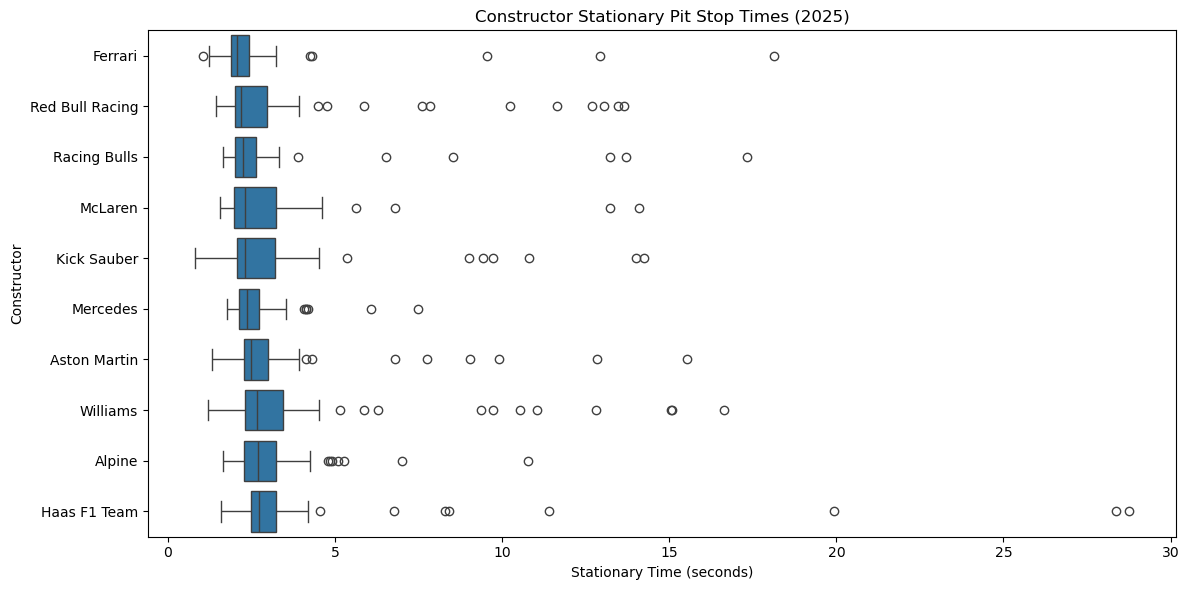

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import fastf1

year = 2025
schedule = fastf1.get_event_schedule(year)
races = schedule[schedule['RoundNumber'] > 0]

all_pit_stats = []

for _, event in races.iterrows():
    try:
        session = fastf1.get_session(year, event['RoundNumber'], 'R')
        # Load telemetry to calculate stationary time (speed == 0 in pit lane)
        session.load(laps=True, telemetry=True, weather=False, messages=False)
        
        if hasattr(session, 'laps') and not session.laps.empty:
            pit_laps = session.laps.dropna(subset=['PitInTime'])
            for _, lap in pit_laps.iterrows():
                try:
                    driver = lap['DriverNumber']
                    t_in = lap['PitInTime']
                    t_out = lap['PitOutTime']
                    
                    # PitOutTime might be on the next lap if crossing start/finish
                    if pd.isna(t_out):
                        next_lap = session.laps[(session.laps['DriverNumber'] == driver) & (session.laps['LapNumber'] == lap['LapNumber'] + 1)]
                        if not next_lap.empty:
                            t_out = next_lap.iloc[0]['PitOutTime']
                    
                    if pd.isna(t_out):
                        continue
                    
                    # Get car telemetry between pit in and pit out
                    tel = session.car_data[driver].slice_by_time(t_in, t_out)
                    stat = tel[tel['Speed'] == 0]
                    
                    if not stat.empty:
                        stat_time = (stat['Time'].max() - stat['Time'].min()).total_seconds()
                        # Filter outliers (e.g. retirements in pits > 60s)
                        if 0 < stat_time < 60:
                            all_pit_stats.append({
                                'Round': event['RoundNumber'],
                                'Event': event['EventName'],
                                'Driver': lap['Driver'],
                                'Team': lap['Team'],
                                'StationaryTime': stat_time
                            })
                except Exception as e:
                    continue
    except Exception as e:
        print(f"Could not load {event['EventName']}: {e}")

df_pits = pd.DataFrame(all_pit_stats)
if not df_pits.empty:
    plt.figure(figsize=(12, 6))
    # Order by median stationary time
    order = df_pits.groupby('Team')['StationaryTime'].median().sort_values().index
    sns.boxplot(x='StationaryTime', y='Team', data=df_pits, order=order)
    plt.title(f'Constructor Stationary Pit Stop Times ({year})')
    plt.xlabel('Stationary Time (seconds)')
    plt.ylabel('Constructor')
    plt.tight_layout()
    plt.show()
else:
    print(f"No pit stop data found for {year}.")
